# **Evolutionary Computing, lab 9 - Report**

**Authors**:
* **Kuba Czech**, 156035
* **Wojciech Nagórka**, 156045

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Description of the problem** ##

We are given a set of nodes, each defined by its x and y coordinates and an associated cost. The task is to select exactly half of the nodes (rounded up if the number is odd) and construct a Hamiltonian cycle that visits each selected node exactly once and returns to the starting node. The objective is to minimize the total sum of both the path length (computed using rounded Euclidean distances between nodes) and the costs of the selected nodes.

## **2. Pseudocode of implemented algorithms** ##

### **2.1. Data**
**Input:**
- $n$: total number of nodes  
- $nodes[i] = (x_i, y_i, cost_i)$ for $i \in [0, n-1]$: array with all nodes
- $distanceMatrix[i][j] = \text{round}\!\left(\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}\right)$: euclidean distance between i-th and j-th node
- $TIME\_LIMIT$: upper limit of running time for ILS algorithm

**Output:**
- $route$: list of nodes forming a closed Hamiltonian cycle  
- $totalCost = \text{distance cost} + \text{node costs}$


### **2.2. Evolutionary algorithm**

```text
function solve():
    population ← fillPopulation()

    while time < TIME_LIMIT:
        if population converged:
            performCataclysm()
        
        parent1 ← random solution from population
        parent2 ← random solution from population different from parent1

        offspring ← recombination(parent1, parent2)

        if random number < mutation_probability:
            offspring ← mutation(offspring)

        if local_search_option:
            offspring ← localSearch(offspring)

        add offspring to population
        remove worst solution from population

    return population



### **2.3. Mutation**
```text
function apply_double_bridge_mutation(route):
    n <- size of route
    if n < 8:
        return  // Too small to mutate

    # Generate 4 distinct, sorted random cut points
    cuts <- pick 4 random distinct indices from 1 to n-1
    sort(cuts)
    
    # Split route into 4 segments based on cuts
    segment_A <- route[0 ... cuts[0]]
    segment_B <- route[cuts[0] ... cuts[1]]
    segment_C <- route[cuts[1] ... cuts[2]]
    segment_D <- route[cuts[2] ... end]

    # Reconnect in specific non-sequential order: A -> D -> C -> B
    new_route <- concatenate(segment_A, segment_D, segment_C, segment_B)
    
    ensure_cycle_closed(new_route)
    
    # Update the original route
    route <- new_route

### **2.4. Recombination Operator 1**
```text
function recombination_operator_1(parent1, parent2):
    # Extract shared topology
    common_nodes <- intersect(nodes of parent1, nodes of parent2)
    common_edges <- intersect(edges of parent1, edges of parent2)

    # Build initial path fragments from common edges
    fragments <- build_fragments_from_edges(common_edges)

    # Add isolated common nodes as single-node fragments
    for node in common_nodes:
        if node not in fragments:
            add [node] to fragments

    # Fill with random nodes until target size (50%)
    target_size <- total_nodes * 0.5
    available_nodes <- all_nodes excluding common_nodes
    shuffle(available_nodes)
    
    while total_nodes_in(fragments) < target_size:
        next_node <- pop(available_nodes)
        add [next_node] to fragments

    # Connect fragments randomly
    shuffle(fragments)
    offspring_route <- empty list
    
    for fragment in fragments:
        if random_boolean() is true:
            reverse(fragment)
        append fragment to offspring_route

    ensure_cycle_closed(offspring_route)
    return offspring_route

### **2.5. Recombination Operator 2**
```text
function recombination_operator_2(parent1, parent2):
    # Initialize child as copy of Parent 1
    child_route <- copy(parent1)
    
    # Filter: Remove nodes that are NOT present in Parent 2
    nodes_in_p2 <- set of nodes in parent2
    remove from child_route any node not in nodes_in_p2

    # Repair the broken cycle using a Greedy 2-Regret Heuristic
    # (This inserts missing nodes to reach target size and closes the loop)
    repairer <- new Greedy2RegretHeuristic()
    repaired_solution <- repairer.repair(child_route)
    
    return repaired_solution

### **2.6. Repair function**

```text
function repair(route):
    regretWeight ← 0.5
    for nodeNumber in route:
        used[nodeNumber] ← true


    while size(route) < targetCount:
        bestNode, bestPos, bestScore ← -1, -1, -∞

        for each unused node j:
            deltas ← []
            for pos in 0 .. size(route):
                if pos == 0:
                    k ← route[0]
                    delta ← distance[j][k] + nodes[j].cost
                else if pos == size(route):
                    i ← route[last]
                    delta ← distance[i][j] + nodes[j].cost
                else:
                    i ← route[pos-1]
                    k ← route[pos]
                    delta ← distance[i][j] + distance[j][k] - distance[i][k] + nodes[j].cost
                deltas.add(delta)
            deltas ← sorted(deltas)
            bestΔ, secondΔ ← deltas[0], deltas[1]
            regret ← secondΔ - bestΔ
            score ← regretWeight * regret - (1 - regretWeight) * bestΔ

            if score > bestScore:
                bestScore ← score
                bestNode ← j
                bestPos ← position of bestΔ in deltas

        insert bestNode at bestPos in route
        used[bestNode] ← true

    route.add(route[0])
    return route
    


### **2.7. Function to fill population**

```text
function fill_population():
    population ← empty list
    while size of population < population_size:
        randomSolution ← generateRandomRoute()
        randomSolution ← localSearch(randomSolution)
        population.add(randomSolution)     

## **3. Results of computational experiments** ##

In [57]:
def read_population(file_name):
    population = pd.read_csv(f"evaluation/{file_name}")
    population = population[['cost', 'route']]

    population['route'] = population['route'].apply(lambda x: [int(node) for node in x[1:-1].split('|')])
    return population

def compute_stats(population):
    mini = population['cost'].min()
    maxi = population['cost'].max()
    avg = population['cost'].mean()
    sd = round(population['cost'].std(), 2)

    return (mini, maxi, avg, sd)

def produce_stats_table(populations: list[tuple[str, pd.DataFrame]]) -> pd.DataFrame:
    to_merge = []
    for pop_name, pop in populations:
        to_merge.append([pop_name, *compute_stats(pop)])

    return pd.DataFrame(to_merge, columns=['method_name', 'min', 'avg', 'max', 'sd'])

def import_and_produce_stats_table(file_names: list[str]) -> list[str, pd.DataFrame]:
    all_populations = []
    for name in file_names:
        method_name = name.split('.')[0]
        curr_pop = read_population(name)

        all_populations.append([method_name, curr_pop])
    return produce_stats_table(all_populations)

#### **3.1. Instance A** 

##### **3.1.1. Results**

In [58]:
stats = import_and_produce_stats_table(["TSPA_Op1_WithLS.csv", "TSPA_Op1_NoLS.csv", "TSPA_Op2_WithLS.csv", "TSPA_Op2_NoLS.csv"])
stats

,method_name,min,avg,max,sd
0,TSPA_Op1_WithLS,69136.0,69785.0,69366.25,147.56
1,TSPA_Op1_NoLS,71477.0,72785.0,72016.40,372.71
2,TSPA_Op2_WithLS,69349.0,69902.0,69552.25,157.91
3,TSPA_Op2_NoLS,69704.0,70983.0,70384.55,327.16


##### **3.1.2. Comparison with results from previous labs**

In [ ]:
stats_lab6 = pd.read_csv('../lab6/evaluation/TSPA_stats.csv') # MSLS + ILS
stats_lab7 = pd.read_csv('../lab7/evaluation/TSPA_stats.csv') # LNS
pd.concat([stats, stats_lab6, stats_lab7]).reset_index(drop=True)

,method_name,min,avg,max,sd
0,TSPA_Op1_WithLS,69136.0,69785.00,69366.25,147.56
1,TSPA_Op1_NoLS,71477.0,72785.00,72016.40,372.71
2,TSPA_Op2_WithLS,69349.0,69902.00,69552.25,157.91
3,TSPA_Op2_NoLS,69704.0,70983.00,70384.55,327.16
4,MSLS,70585.0,71364.65,71825.00,298.91
5,ILS,69152.0,69471.40,69895.00,229.85
6,LNSWithLS,69450.0,69936.50,70425.00,271.51
7,LNSWithoutLS,69492.0,70211.55,70880.00,398.62


#### **3.2. Instance B** 

##### **3.2.1. Results**

In [62]:
stats = import_and_produce_stats_table(["TSPB_Op1_WithLS.csv", "TSPB_Op1_NoLS.csv", "TSPB_Op2_WithLS.csv", "TSPB_Op2_NoLS.csv"])
stats

,method_name,min,avg,max,sd
0,TSPB_Op1_WithLS,43473.0,43943.0,43706.75,128.19
1,TSPB_Op1_NoLS,45925.0,47182.0,46573.10,404.03
2,TSPB_Op2_WithLS,43532.0,44599.0,43908.30,259.97
3,TSPB_Op2_NoLS,43785.0,45203.0,44441.30,384.97


#### **3.2.2. Comparison with results from previous labs**

In [63]:
stats_lab6 = pd.read_csv('../lab6/evaluation/TSPB_stats.csv') # MSLS + ILS
stats_lab7 = pd.read_csv('../lab7/evaluation/TSPB_stats.csv') # LNS
pd.concat([stats, stats_lab6, stats_lab7]).reset_index(drop=True)

,method_name,min,avg,max,sd
0,TSPB_Op1_WithLS,43473.0,43943.00,43706.75,128.19
1,TSPB_Op1_NoLS,45925.0,47182.00,46573.10,404.03
2,TSPB_Op2_WithLS,43532.0,44599.00,43908.30,259.97
3,TSPB_Op2_NoLS,43785.0,45203.00,44441.30,384.97
4,MSLS,44790.0,45583.15,46322.00,388.16
5,ILS,43477.0,43859.30,44552.00,316.47
6,LNSWithLS,43652.0,44211.60,45799.00,493.60
7,LNSWithoutLS,43671.0,44906.85,46604.00,829.88


## **4. 2D Visualization** ##

In [76]:
def get_best_solution(population):
    return np.array(population['route'].loc[population['cost'].argmin()])

### **Reading TSP A and TSP B instances** ##

In [77]:
tsp_a = pd.read_csv('../data/TSPA.csv', sep=';', header=None)
tsp_a.columns = ['x', 'y', 'cost']

tsp_b = pd.read_csv('../data/TSPB.csv', sep=';', header=None)
tsp_b.columns = ['x', 'y', 'cost']

### **Reading files with best solutions** ##

In [78]:
tsp_a_op1_with_ls = get_best_solution(read_population('TSPA_Op1_WithLS.csv'))
tsp_a_op1_without_ls = get_best_solution(read_population('TSPA_Op1_NoLS.csv'))
tsp_a_op2_with_ls = get_best_solution(read_population('TSPA_Op2_WithLS.csv'))
tsp_a_op2_without_ls = get_best_solution(read_population('TSPA_Op2_NoLS.csv'))

In [79]:
tsp_b_op1_with_ls = get_best_solution(read_population('TSPB_Op1_WithLS.csv'))
tsp_b_op1_without_ls = get_best_solution(read_population('TSPB_Op1_NoLS.csv'))
tsp_b_op2_with_ls = get_best_solution(read_population('TSPB_Op2_WithLS.csv'))
tsp_b_op2_without_ls = get_best_solution(read_population('TSPB_Op2_NoLS.csv'))

In [80]:
def plot_tsp(tsp, solution, title):
    unused_nodes = np.array(set(tsp.index).difference(solution))
    X = tsp['x'].loc[solution].values
    Y = tsp['y'].loc[solution].values
    costs = tsp['cost'].loc[solution].values

    X_unused = tsp['x'].loc[unused_nodes].values
    Y_unused = tsp['y'].loc[unused_nodes].values
    costs_unused = tsp['cost'].loc[unused_nodes].values

    plt.figure(figsize=(15, 9))
    plt.scatter(X, Y, s=costs, color='red', alpha=0.4, label='Data points')
    plt.scatter(X_unused, Y_unused, s=costs_unused, color="grey", alpha=0.4, label="Unused nodes")
    plt.scatter(X, Y, color='blue')
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')

    plt.plot(X, Y, color='blue', linestyle='-', linewidth=2, label='Connecting line')

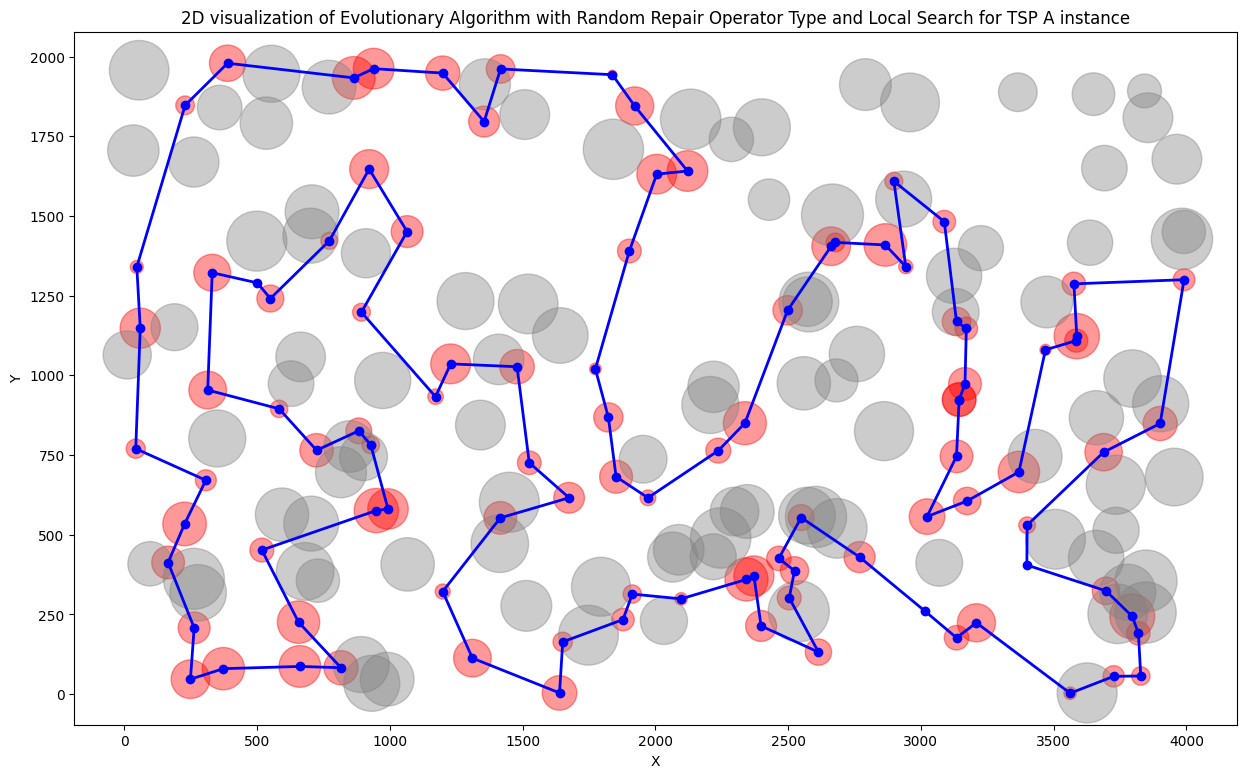

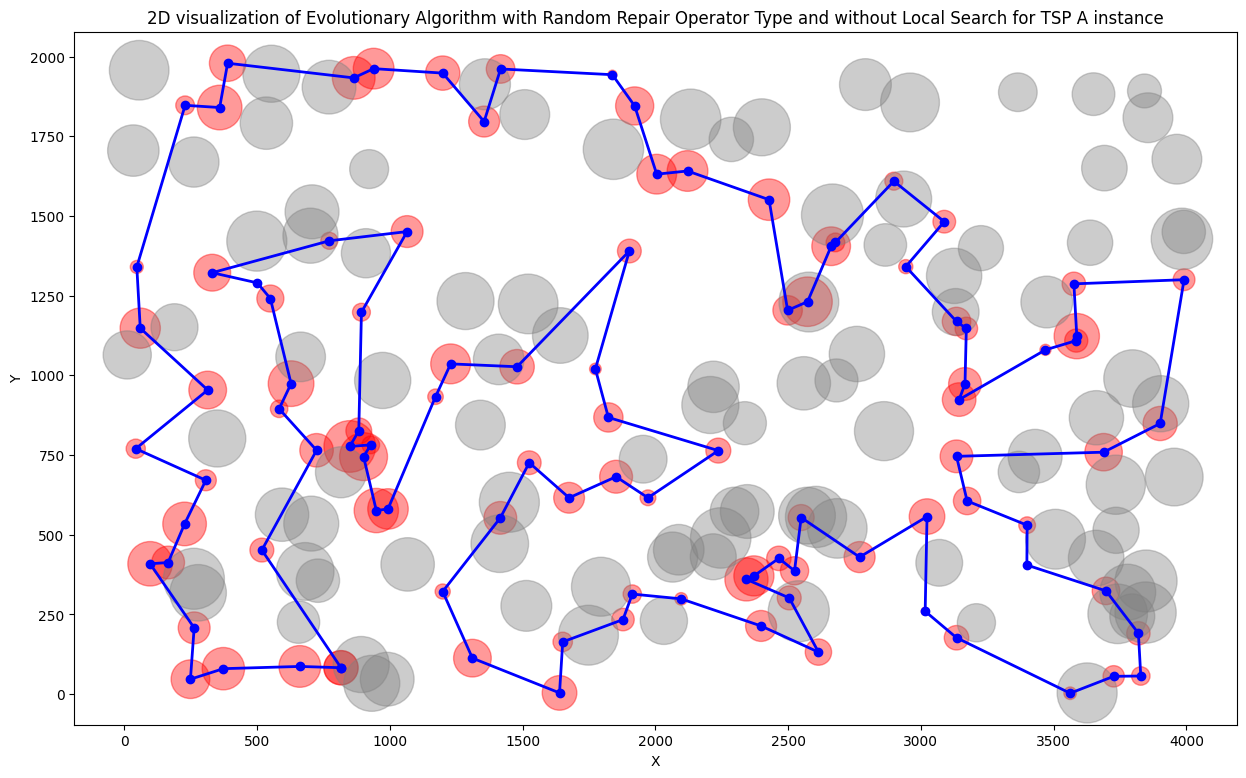

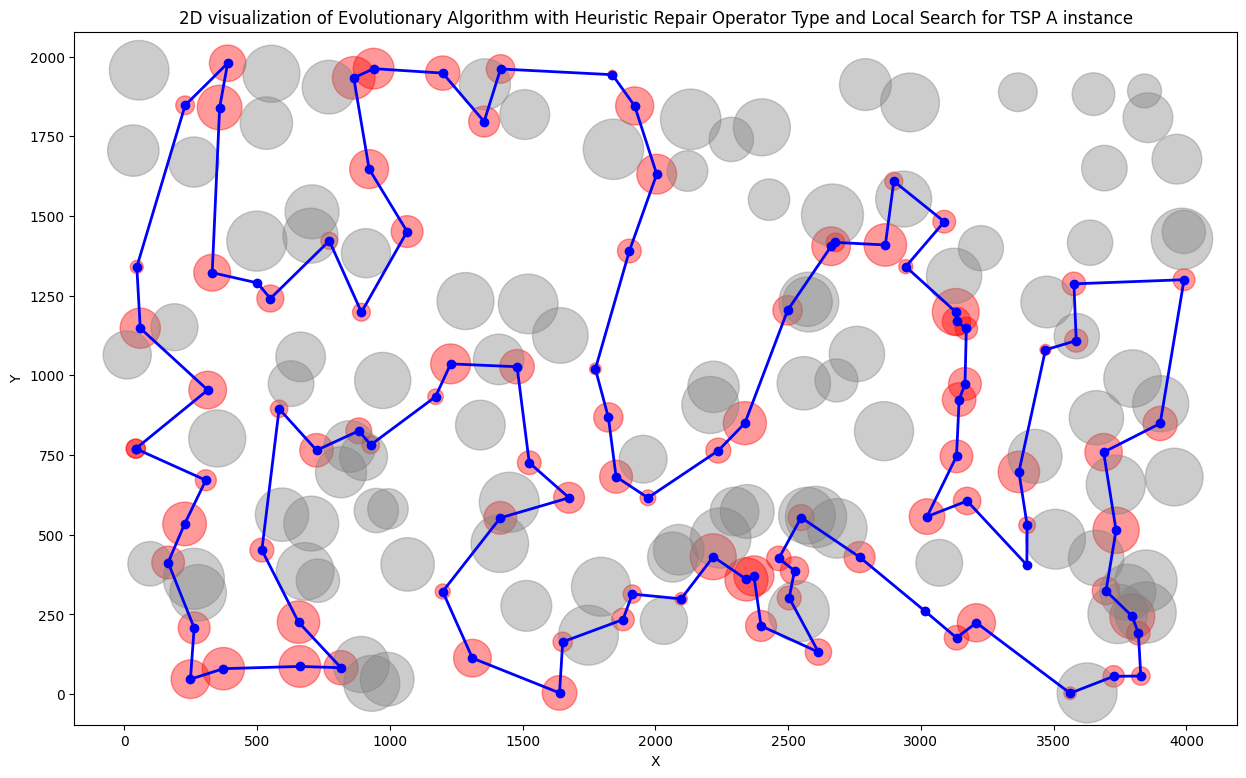

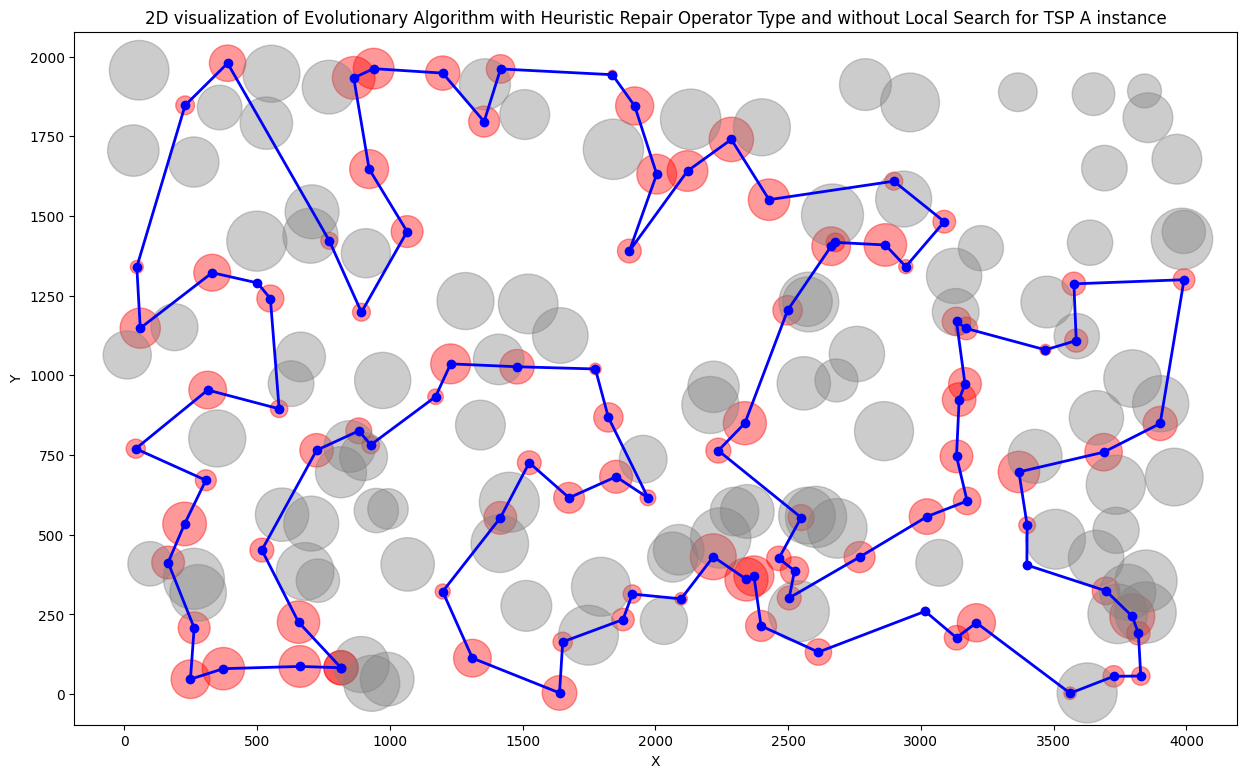

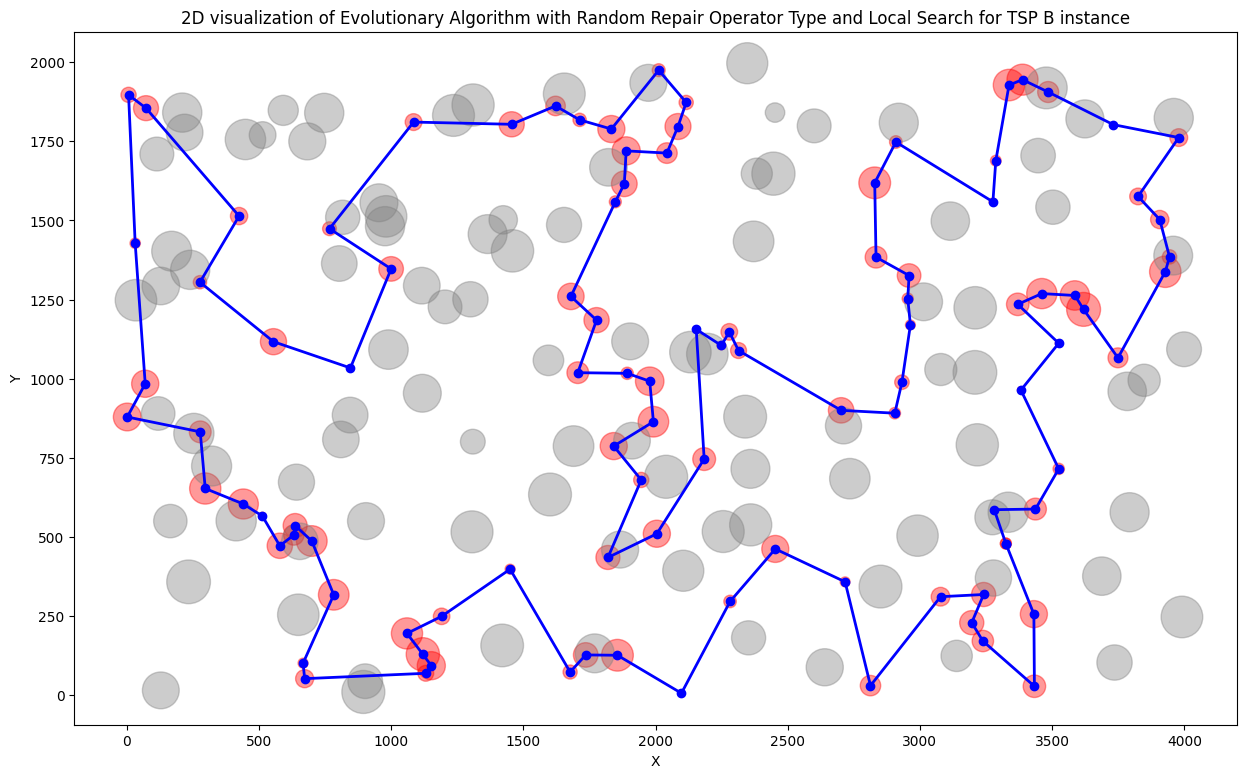

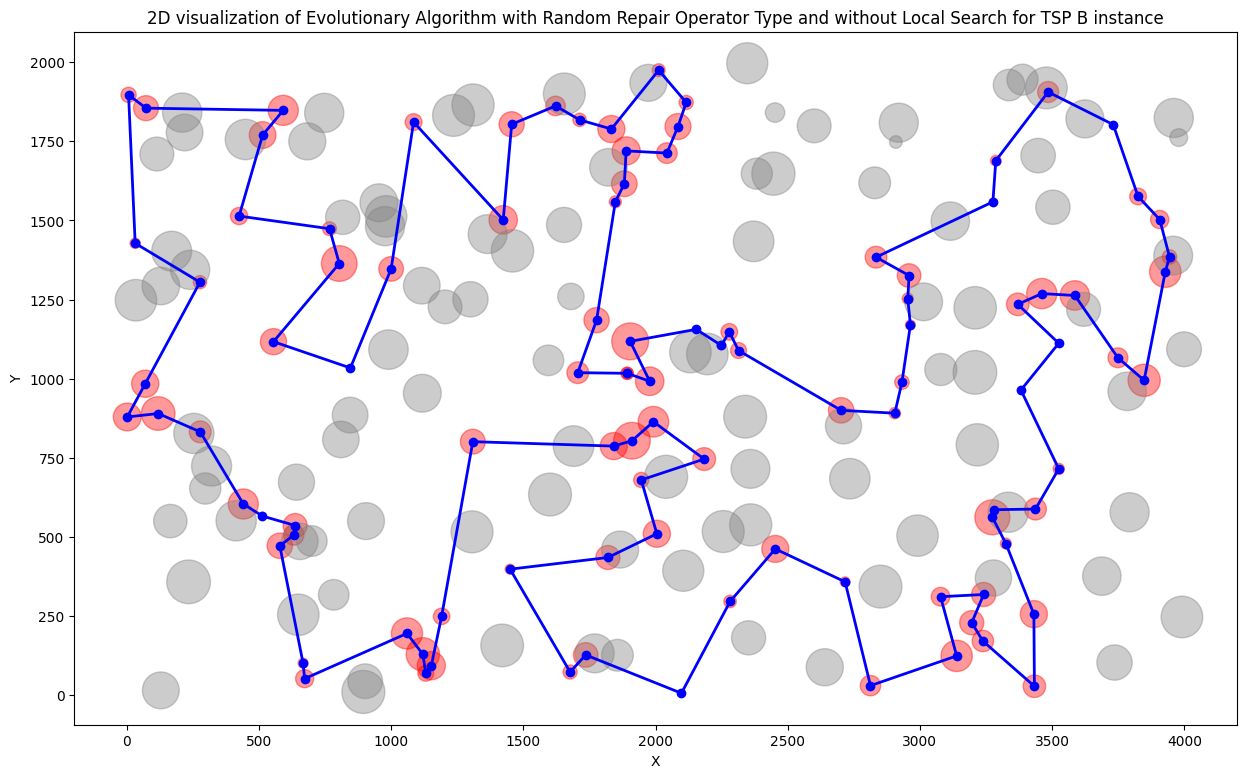

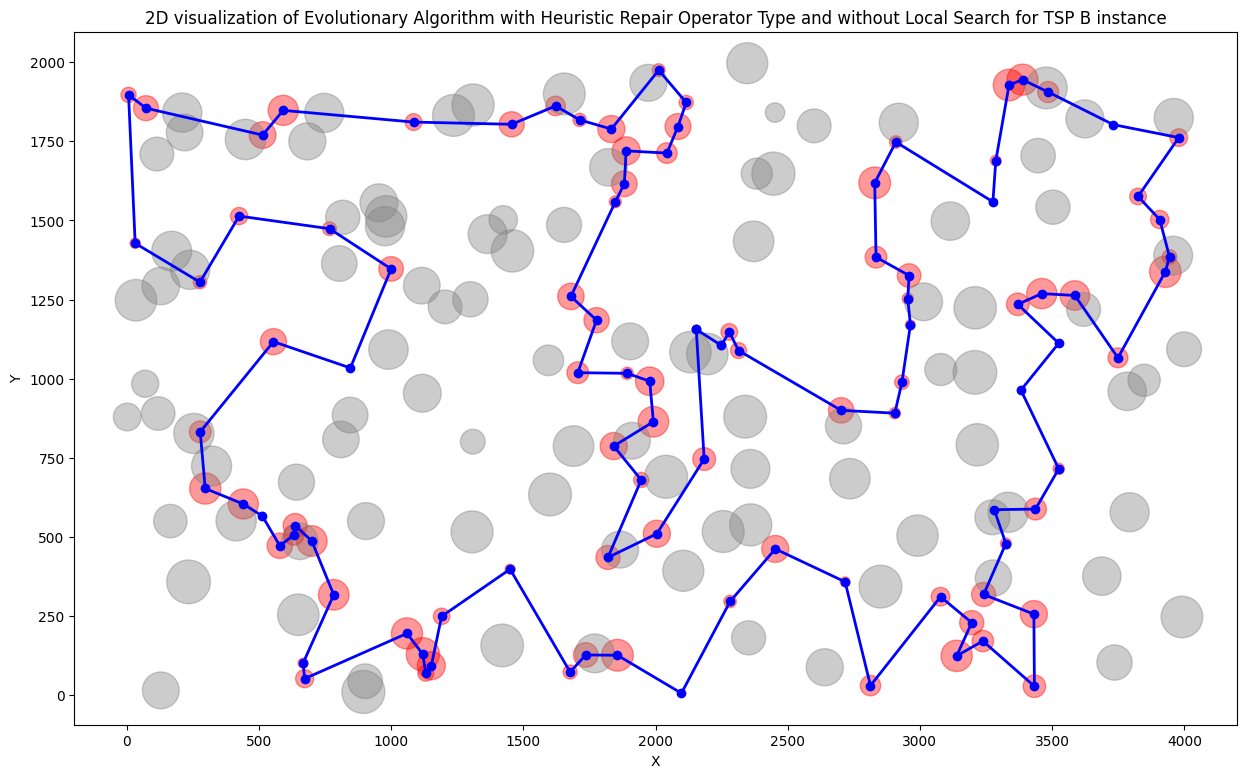

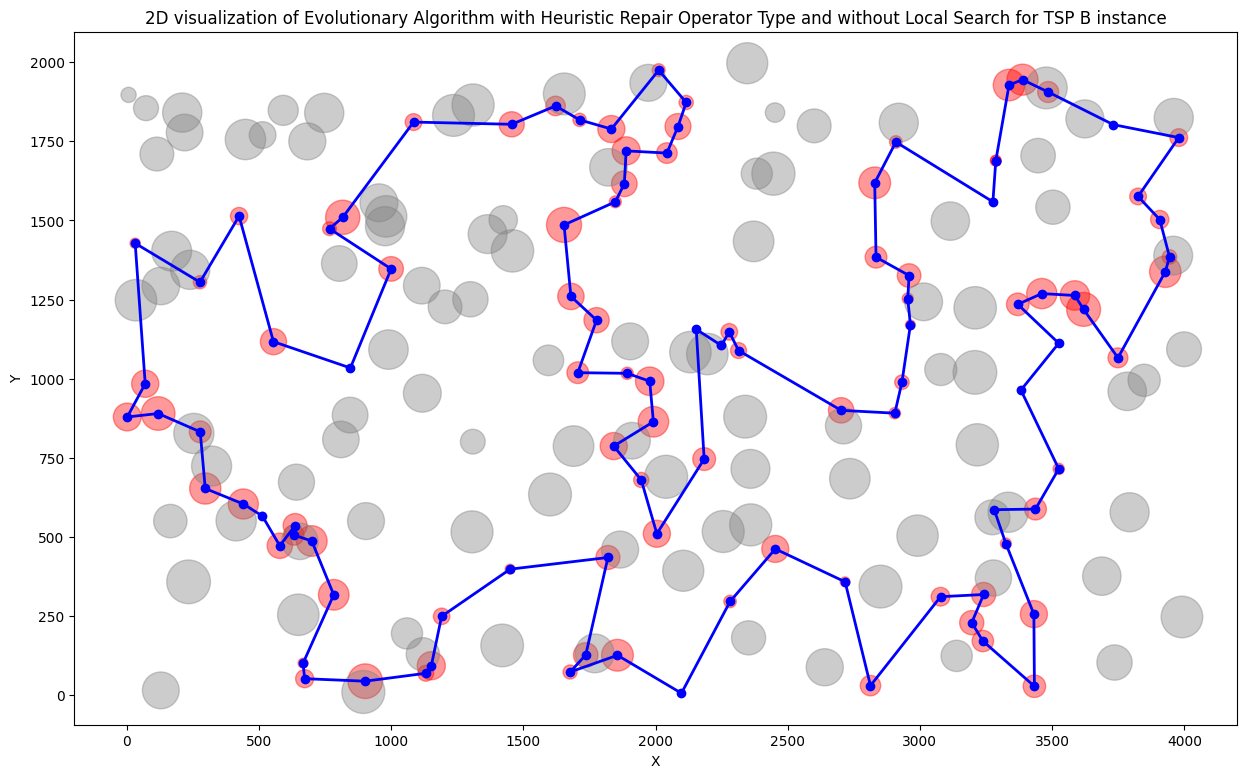

In [81]:
instances = [
    (tsp_a, tsp_a_op1_with_ls, '2D visualization of Evolutionary Algorithm with Random Repair Operator Type and Local Search for TSP A instance'),
    (tsp_a, tsp_a_op1_without_ls, '2D visualization of Evolutionary Algorithm with Random Repair Operator Type and without Local Search for TSP A instance'),
    (tsp_a, tsp_a_op2_with_ls, '2D visualization of Evolutionary Algorithm with Heuristic Repair Operator Type and Local Search for TSP A instance'),
    (tsp_a, tsp_a_op2_without_ls, '2D visualization of Evolutionary Algorithm with Heuristic Repair Operator Type and without Local Search for TSP A instance'),
    (tsp_b, tsp_b_op1_with_ls, '2D visualization of Evolutionary Algorithm with Random Repair Operator Type and Local Search for TSP B instance'),
    (tsp_b, tsp_b_op1_without_ls, '2D visualization of Evolutionary Algorithm with Random Repair Operator Type and without Local Search for TSP B instance'),
    (tsp_b, tsp_b_op2_with_ls, '2D visualization of Evolutionary Algorithm with Heuristic Repair Operator Type and without Local Search for TSP B instance'),
    (tsp_b, tsp_b_op2_without_ls, '2D visualization of Evolutionary Algorithm with Heuristic Repair Operator Type and without Local Search for TSP B instance')
]
for i in instances:
    plot_tsp(*i)

## **5. Display of the results** ##

### **5.1. TSP A instance** ###
#### **5.1.1. Evolutionary Algorithm with Random Repair Operator Type and Local Search Solution** ####

In [82]:
tsp_a_op1_with_ls

array([ 55,  57, 129,  92, 179, 185,  40, 119, 165,  90,  81, 196, 145,
        78,  31,  56, 113, 175, 171,  16,  25,  44, 120,   2, 152,  97,
         1, 101,  75,  86,  26, 100,  53, 180, 154, 135,  70, 127, 123,
       162, 133, 151,  51, 118,  59, 115,  46,  68, 139,  41, 193, 159,
       181,  42,  43, 116,  65, 149, 131, 184,  84, 112,   4, 190,  10,
       177,  54,  48, 160,  34, 146,  22,  18, 108, 140,  93, 117,   0,
       143, 183,  89, 186,  23, 137, 176,  80,  79,  63,  94, 124, 148,
         9,  62, 102,  49, 144,  14, 178, 106,  52,  55])

#### **5.1.2. Evolutionary Algorithm with Heuristic Random Operator Type and without Local Search Solution** ####

In [83]:
tsp_a_op1_without_ls

array([112, 184,  43,  42,   5,  41, 193, 159, 139,  46, 115, 116, 105,
        65,  47, 131, 149,  59, 118,  51, 137, 176,  80,  94,  63,  79,
       133, 151, 162, 123, 127,  70, 135, 154, 180,  53,  86,  75, 101,
       100,  26,  97,   1, 152,   2, 129, 120,  44,  16, 171, 175, 113,
        31,  78, 145,  92,  57, 196,  81,  90, 165, 119,  40, 185,  55,
        52, 106, 178,  49,  14, 144,  62,   9,  37, 148,  15, 186,  23,
        89, 183, 143,   0, 117,  93, 140, 108,  69,  18,  22, 146, 181,
        34, 160,  48,  54,  30, 177,  10, 190,   4, 112])

#### **5.1.3.Evolutionary Algorithm with Heuristic Repair Operator Type and Local Search Solution** ####

In [84]:
tsp_a_op2_with_ls

array([ 34, 181, 146,  22,  18, 108,  69, 159, 193,  41, 139, 115,  46,
        68, 140,  93, 117,   0, 143, 183,  89,  23, 137, 176,  80,  79,
        63,  94, 124, 148,   9,  62, 102, 144,  14,  49,   3, 178, 106,
        52,  55,  57, 129,  92,  78, 145, 179, 185,  40, 165,  90,  81,
       196, 157,  31,  56, 113, 175, 171,  16,  25,  44, 120,   2, 152,
        97,   1, 101,  75,  86,  26, 100, 121,  53, 180, 154, 135,  70,
       127, 123, 162, 133, 151,  51, 118,  59,  65, 116,  43,  42, 184,
        84, 112,   4, 190,  10, 177,  54,  48, 160,  34])

#### **5.1.4. Evolutionary Algorithm with Heuristic Repair Operator Type and without Local Search Solution** ####

In [85]:
tsp_a_op2_without_ls

array([112,   4, 190,  10, 177,  54,  48, 160,  34, 181,  42,  41, 193,
       159, 146,  22,  18, 108, 139, 115,  46,  68, 140,  93, 117,   0,
       143, 183,  89,  23, 137, 186, 114,  15, 144,  14,  49, 102,  62,
         9, 148, 124,  94, 152,  97,   1, 101,   2, 129,  92,  57,  55,
        52, 178, 106, 185,  40, 165,  90,  81, 196, 179, 145,  78,  31,
        56, 113, 175, 171,  16,  25,  44, 120,  75,  86,  26, 100, 121,
        53, 180, 154, 135,  70, 127, 123, 162, 151, 133,  79,  63,  80,
       176,  51, 118,  59,  65, 116,  43, 184,  84, 112])

### **5.2. TSP B instance** ###
#### **5.2.1. Evolutionary Algorithm with Random Repair Operator Type and Local Search Solution** ####

In [86]:
tsp_b_op1_with_ls

array([113, 176, 194, 166,  86, 185,  95, 130,  99,  22, 179,  66,  94,
        47, 148,  60,  20,  28, 149,   4, 140, 183, 152, 170,  34,  55,
        18,  62, 124, 106, 143,  35, 109,   0,  29, 111,  82,  21,   8,
       104, 144, 160,  33, 138,  11, 139, 168, 195,  13, 145,  15,   3,
        70, 132, 169, 188,   6, 147,  90,  51, 121, 131, 135, 122, 107,
        40,  63,  38,  27,   1, 156, 198, 117, 193,  31,  54,  73, 136,
       190,  80, 175,  78, 142,  45,   5, 177,  36,  61,  91, 141,  77,
        81, 153, 187, 163, 103,  89, 127, 137, 114, 113])

#### **5.2.2. Evolutionary Algorithm with Heuristic Random Operator Type and without Local Search Solution** ####

In [87]:
tsp_b_op1_without_ls

array([ 33, 138,  11, 168, 195,  13, 145,  15,   3,  70, 132, 169, 188,
         6, 134, 147,  51, 121, 131, 125,  90, 122, 133,  10, 107,  40,
        63, 135,  38,  27,  16,   1, 198, 117,  54,  31, 193, 190,  80,
        45, 142, 175,  78,   5,  25, 104,  56, 144, 111,   8,  82,  21,
       177,  36,  61, 141,  77,  81, 153, 187, 165, 163, 103,  89, 127,
       137, 114, 113, 180, 176, 194, 166,  86, 185,  95, 130,  99, 179,
       172,  66,  94,  47, 148,  20,  28, 140, 183,  34,  55,  18,  62,
       124, 106, 143,  35, 109,   0,  29,  49, 160,  33])

#### **5.2.3.Evolutionary Algorithm with Heuristic Repair Operator Type and Local Search Solution** ####

In [88]:
tsp_b_op2_with_ls

array([ 29,   0, 109,  35, 143, 106, 124,  62,  18,  55,  34, 170, 152,
       183, 140,   4, 149,  28,  20,  60, 148,  47,  94,  66, 179,  99,
       130,  95, 185,  86, 166, 194, 176, 113, 103, 114, 137, 127, 165,
        89, 163, 187, 153,  81,  77, 141,  91,  61,  36, 177,   5,  78,
       175, 142,  45,  80, 190, 136,  73,  54,  31, 193, 117, 198, 156,
         1, 131, 121,  51,  90, 122, 135,  63,  40, 107, 133,  10, 147,
         6, 188, 169, 132,  70,   3,  15, 145,  13, 195, 168, 139,  11,
       138,  33, 160, 144, 104,   8,  21,  82, 111,  29])

#### **5.2.4. Evolutionary Algorithm with Heuristic Repair Operator Type and without Local Search Solution** ####

In [89]:
tsp_b_op2_without_ls

array([140, 183, 152, 170,  34,  55,  18,  62, 124, 106, 143,  35, 109,
         0,  29, 111,  82,   8, 104, 144, 160,  33, 138,  11, 139,  43,
       168, 195,  13, 145,  15,   3,  70, 132, 169, 188,   6, 147, 191,
        90,  51, 121, 131, 122, 135,  63,  38,  27,  16,   1, 156, 198,
       117, 193,  54,  31,  73, 136, 190,  80, 162, 175,  78,   5, 177,
        21,  61,  36,  91, 141,  77,  81, 153, 187, 163, 103,  89, 127,
       137, 114, 113, 176, 194, 166,  86, 185,  95, 130,  99,  22, 179,
        66,  94,  47, 148,  60,  20,  28, 149,   4, 140])

## **6. Usage of solution checker**

Solution checker was used for all computed above solutions and value of objective functions are correct.

## **7. Link to the source code** ##

https://github.com/WojtekNagorka/Evolutionary-computation/tree/main/lab10

## **8. Conclusions**

**TODO**